##Importing Libraries for the Project

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score,classification_report,roc_auc_score


##Data Reading

In [ ]:
from pandas import read_csv,get_dummies,DataFrame
stroke_dataset=read_csv('/content/stroke.csv')

In [ ]:
stroke_dataset.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
2,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
3,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
4,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1


In [ ]:
stroke_dataset.head(5)

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
2,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
3,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
4,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1


In [ ]:
stroke_dataset.tail()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
4976,Male,41.0,0,0,No,Private,Rural,70.15,29.8,formerly smoked,0
4977,Male,40.0,0,0,Yes,Private,Urban,191.15,31.1,smokes,0
4978,Female,45.0,1,0,Yes,Govt_job,Rural,95.02,31.8,smokes,0
4979,Male,40.0,0,0,Yes,Private,Rural,83.94,30.0,smokes,0
4980,Female,80.0,1,0,Yes,Private,Urban,83.75,29.1,never smoked,0


In [ ]:
stroke_dataset.tail(5)

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
4976,Male,41.0,0,0,No,Private,Rural,70.15,29.8,formerly smoked,0
4977,Male,40.0,0,0,Yes,Private,Urban,191.15,31.1,smokes,0
4978,Female,45.0,1,0,Yes,Govt_job,Rural,95.02,31.8,smokes,0
4979,Male,40.0,0,0,Yes,Private,Rural,83.94,30.0,smokes,0
4980,Female,80.0,1,0,Yes,Private,Urban,83.75,29.1,never smoked,0


##Data Size



In [ ]:
stroke_dataset.shape

(4981, 11)

##Data Descripition

In [ ]:
stroke_dataset.describe()

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,4981.000000,4981.000000,4981.000000,4981.000000,4962.000000,4981.000000
mean,43.419859,0.096165,0.055210,105.943562,28.496715,0.049789
std,22.662755,0.294848,0.228412,45.075373,6.794855,0.217531
min,0.080000,0.000000,0.000000,55.120000,14.000000,0.000000
25%,25.000000,0.000000,0.000000,77.230000,23.700000,0.000000
50%,45.000000,0.000000,0.000000,91.850000,28.100000,0.000000
75%,61.000000,0.000000,0.000000,113.860000,32.600000,0.000000
max,82.000000,1.000000,1.000000,271.740000,48.900000,1.000000


##Data Information

In [ ]:
stroke_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4981 entries, 0 to 4980
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             4981 non-null   object 
 1   age                4981 non-null   float64
 2   hypertension       4981 non-null   int64  
 3   heart_disease      4981 non-null   int64  
 4   ever_married       4981 non-null   object 
 5   work_type          4981 non-null   object 
 6   Residence_type     4981 non-null   object 
 7   avg_glucose_level  4981 non-null   float64
 8   bmi                4962 non-null   float64
 9   smoking_status     4981 non-null   object 
 10  stroke             4981 non-null   int64  
dtypes: float64(3), int64(3), object(5)
memory usage: 428.2+ KB


##Data Summary

In [ ]:
summary=stroke_dataset.describe()
summary = summary
summary

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,4981.000000,4981.000000,4981.000000,4981.000000,4962.000000,4981.000000
mean,43.419859,0.096165,0.055210,105.943562,28.496715,0.049789
std,22.662755,0.294848,0.228412,45.075373,6.794855,0.217531
min,0.080000,0.000000,0.000000,55.120000,14.000000,0.000000
25%,25.000000,0.000000,0.000000,77.230000,23.700000,0.000000
50%,45.000000,0.000000,0.000000,91.850000,28.100000,0.000000
75%,61.000000,0.000000,0.000000,113.860000,32.600000,0.000000
max,82.000000,1.000000,1.000000,271.740000,48.900000,1.000000


##Checking for Missing Value

In [ ]:
stroke_dataset.isnull().sum()

,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,19
smoking_status,0


##I noticed that the bmi column have some missing values so I will use average mean to fill those missing values

In [ ]:
stroke_dataset['bmi'].fillna(stroke_dataset.bmi.mean())

,bmi
0,36.6
1,32.5
2,34.4
3,24.0
4,29.0
...,...
4976,29.8
4977,31.1
4978,31.8
4979,30.0


##I will put the filled-in values into the Dataset

In [ ]:
stroke_dataset['bmi']=stroke_dataset['bmi'].fillna(stroke_dataset.bmi.mean())

#Data Information after filling the missing values

In [ ]:
stroke_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4981 entries, 0 to 4980
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             4981 non-null   object 
 1   age                4981 non-null   float64
 2   hypertension       4981 non-null   int64  
 3   heart_disease      4981 non-null   int64  
 4   ever_married       4981 non-null   object 
 5   work_type          4981 non-null   object 
 6   Residence_type     4981 non-null   object 
 7   avg_glucose_level  4981 non-null   float64
 8   bmi                4981 non-null   float64
 9   smoking_status     4981 non-null   object 
 10  stroke             4981 non-null   int64  
dtypes: float64(3), int64(3), object(5)
memory usage: 428.2+ KB


##EXPLORATORY DATA ANALYSIS

##Count Value

##Gender Count

In [ ]:
stroke_dataset['gender'].value_counts()

,count
gender,
Female,2907
Male,2074


##Pie chart showing gender distribution

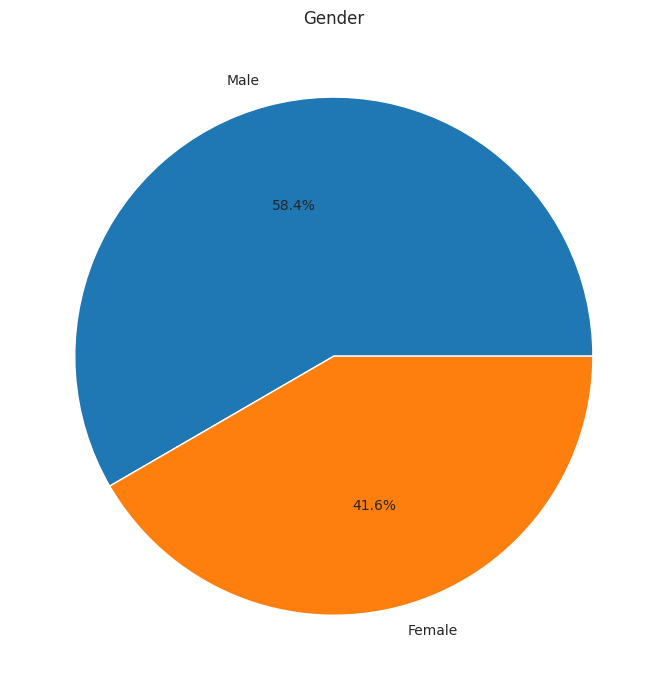

In [ ]:
import matplotlib.pyplot as plt
x = [2907, 2074
]
labels = ['Male','Female',]
fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(x, labels=labels, autopct='%.1f%%')
ax.set_title('Gender')
plt.tight_layout()

##Resident Type Count

##Bar chart showing Resident Type distribution

In [ ]:
stroke_dataset['Residence_type'].value_counts()

,count
Residence_type,
Urban,2532
Rural,2449


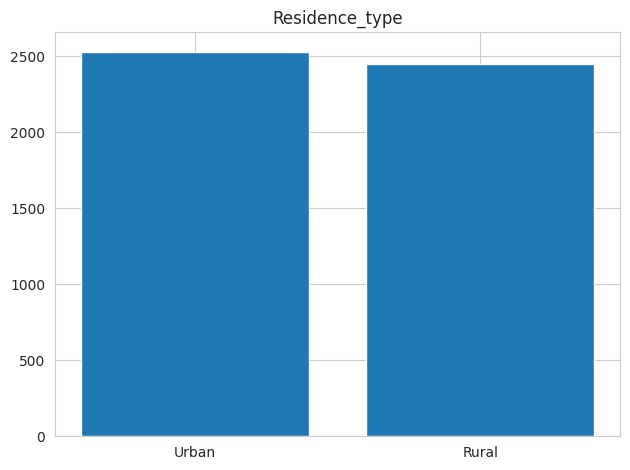

In [ ]:
# Libraries
import numpy as np
import matplotlib.pyplot as plt

# Make a random dataset:
height = [2532, 2449]
bars = ('Urban', 'Rural')
y_pos = np.arange(len(bars))


# Create bars
plt.bar(y_pos, height)
# Create names on the x-axis
plt.xticks(y_pos, bars)
plt.title("Residence_type")
plt.tight_layout()
# Show graphic
plt.show()



##Ever Married Count

In [ ]:
stroke_dataset['ever_married'].value_counts()

,count
ever_married,
Yes,3280
No,1701


##Pie chart showing Ever Married Count

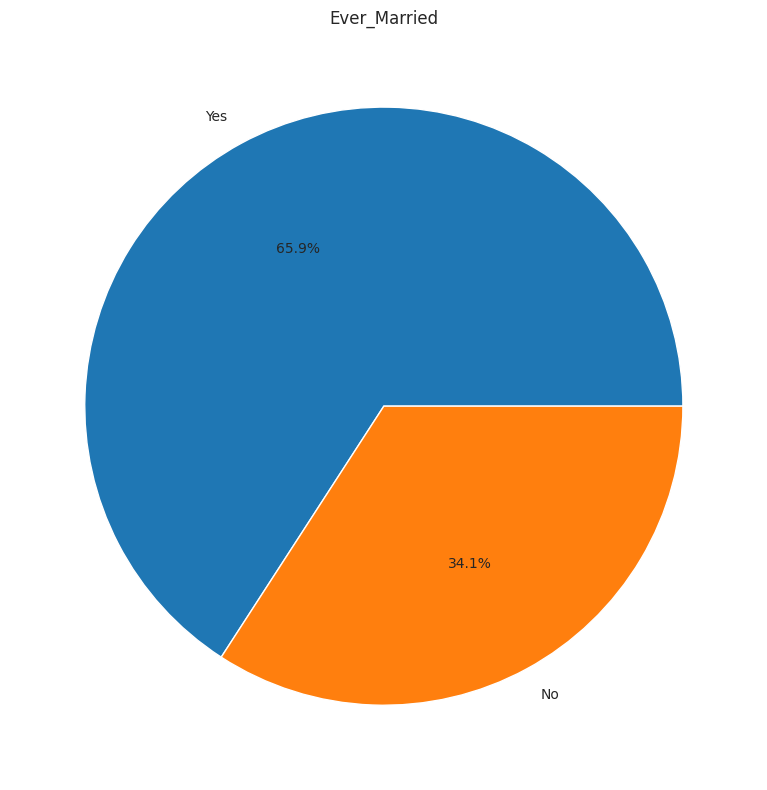

In [ ]:
import matplotlib.pyplot as plt
x = [3280, 1701]
labels = ['Yes', 'No',]
fig, ax = plt.subplots(figsize=(8, 8))
ax.pie(x, labels=labels, autopct='%.1f%%')
ax.set_title('Ever_Married')
plt.tight_layout()

##Work Type Count

In [ ]:
stroke_dataset['work_type'].value_counts()

,count
work_type,
Private,2860
Self-employed,804
children,673
Govt_job,644


##Bar Graph Showing Work Type

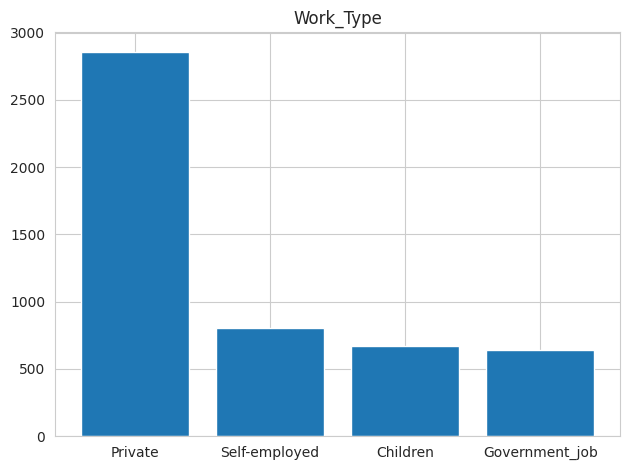

In [ ]:
# Libraries
import numpy as np
import matplotlib.pyplot as plt

# Make a random dataset:
height = [2860, 804, 673, 644]
bars = ('Private', 'Self-employed', 'Children', 'Government_job')
y_pos = np.arange(len(bars))


# Create bars
plt.bar(y_pos, height)
# Create names on the x-axis
plt.xticks(y_pos, bars)
plt.title("Work_Type")
plt.tight_layout()
# Show graphic
plt.show()

##Smoking Status Count

In [ ]:
stroke_dataset['smoking_status'].value_counts()

,count
smoking_status,
never smoked,1838
Unknown,1500
formerly smoked,867
smokes,776


##Bar Graph Showing Smoking Status

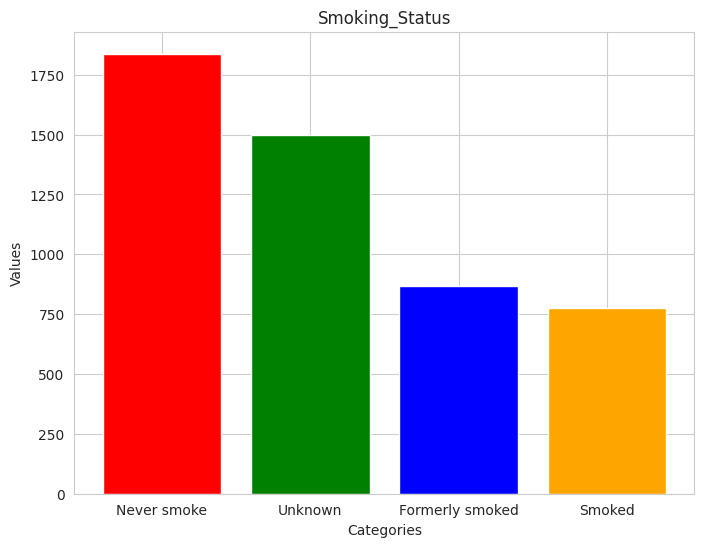

In [ ]:
import matplotlib.pyplot as plt

categories = ['Never smoke', 'Unknown', 'Formerly smoked', 'Smoked']
values = [1838, 1500, 867, 776]
colors = ['red', 'green', 'blue', 'orange']

plt.figure(figsize=(8, 6))
plt.bar(categories, values, color=colors)
plt.title('Smoking_Status')
plt.xlabel('Categories')
plt.ylabel('Values')
plt.show()

##Hypertension Status Count

In [ ]:
stroke_dataset['hypertension'].value_counts()

,count
hypertension,
0,4502
1,479


##Bar Graph Showing Hypertension Status

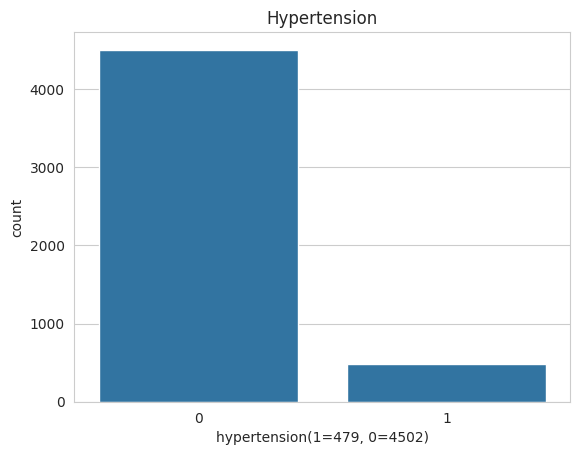

In [ ]:
sns.countplot(x='hypertension', data=stroke_dataset)
plt.title('Hypertension')
plt.xlabel('hypertension(1=479, 0=4502)')
colors = ['green', 'blue']
plt.show()

##Heart disease Count

In [ ]:
stroke_dataset['heart_disease'].value_counts()

,count
heart_disease,
0,4706
1,275


##Bar Graph Showing Heart disease

<ipython-input-499-dd9c656152b5>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = stroke_dataset['heart_disease'], palette= 'winter')


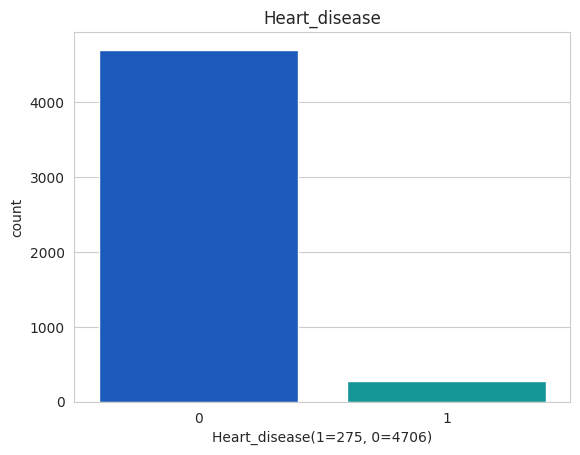

In [ ]:
import matplotlib.pyplot as plt

sns.countplot(x = stroke_dataset['heart_disease'], palette= 'winter')
plt.xlabel('heart_disease');
plt.title('Heart_disease')
plt.xlabel('Heart_disease(1=275, 0=4706)')
plt.show()

##Count of People affected by Stroke

In [ ]:
stroke_dataset['stroke'].value_counts()

,count
stroke,
0,4733
1,248


##Bar Graph showing number of people affected by stroke

<ipython-input-501-93069fa14e23>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = stroke_dataset['stroke'], palette= 'autumn')


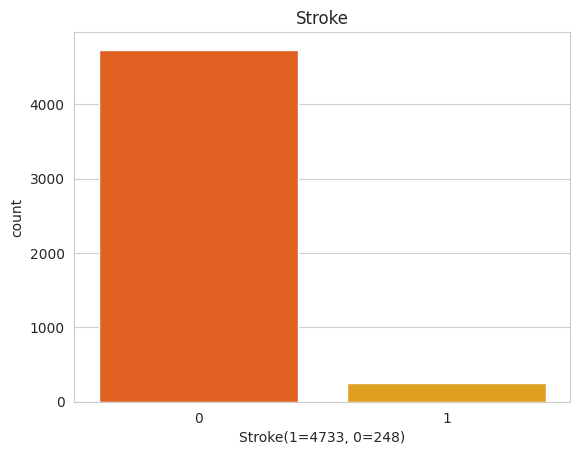

In [ ]:
import matplotlib.pyplot as plt

sns.countplot(x = stroke_dataset['stroke'], palette= 'autumn')
plt.xlabel('stroke');
plt.title('Stroke')
plt.xlabel('Stroke(1=4733, 0=248)')
plt.show()

##Age Distribution

In [ ]:
stroke_dataset['age'].value_counts()

,count
age,
78.00,102
57.00,92
54.00,85
51.00,84
79.00,84
...,...
1.16,3
0.48,3
0.40,2


##Bar Graph showing Age Distribution

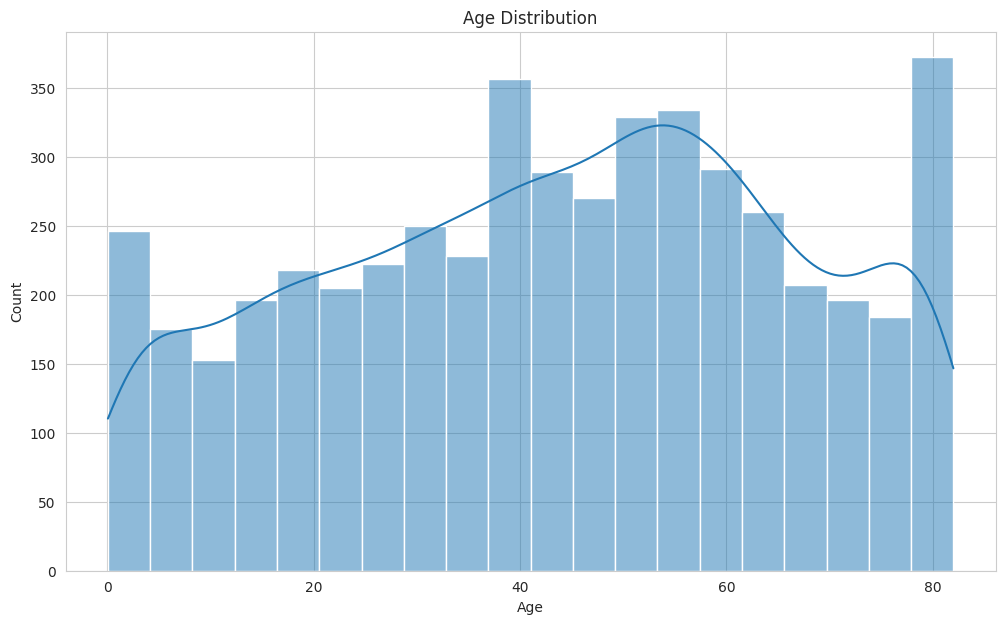

In [ ]:
plt.figure(figsize=(12,7))
sns.histplot(data=stroke_dataset, x="age", kde=True)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.show()

##Average Glucose Level

In [ ]:
stroke_dataset['avg_glucose_level'].unique()

array([228.69, 105.92, 171.23, ..., 191.15,  95.02,  83.94])

##Average Glucose Level in a DataFrame

In [ ]:
stroke_dataset['avg_glucose_level'].unique(),DataFrame

(array([228.69, 105.92, 171.23, ..., 191.15,  95.02,  83.94]),
 pandas.core.frame.DataFrame)

##Bar Graph showing Average Glucose Level Distribution

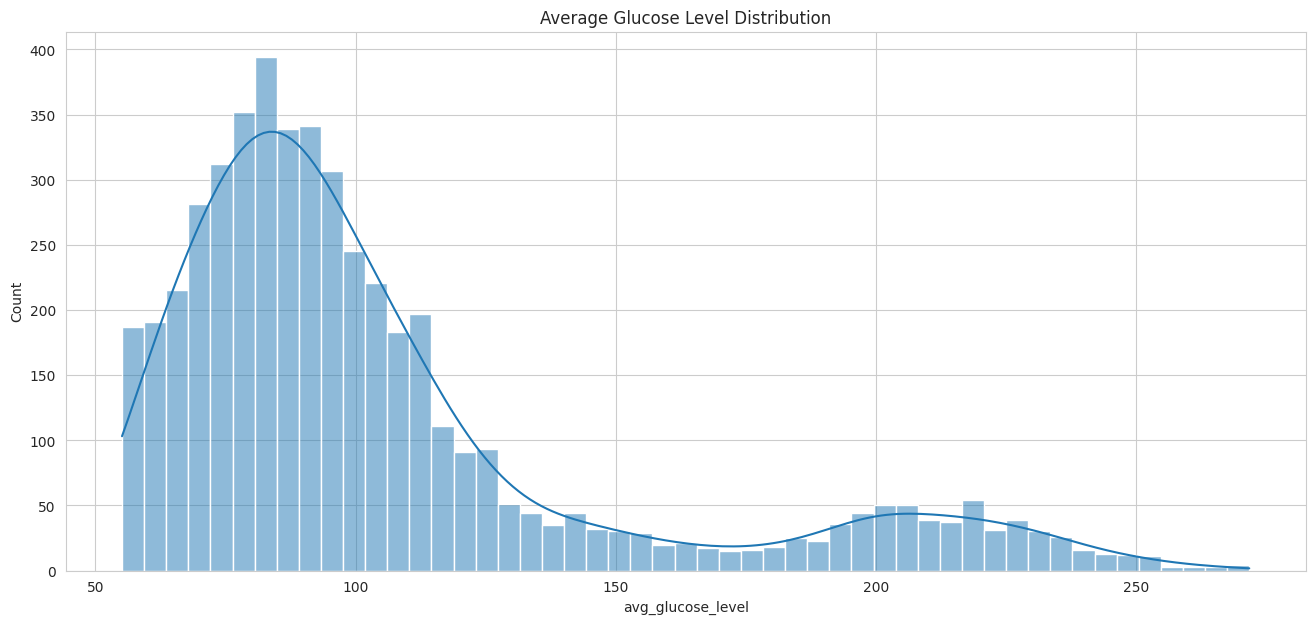

In [ ]:
plt.figure(figsize=(16,7))
sns.histplot(data=stroke_dataset, x="avg_glucose_level", kde=True)
plt.title('Average Glucose Level Distribution')
plt.xlabel('avg_glucose_level')
plt.show()




##BMI Distribution

In [ ]:
stroke_dataset['bmi'].value_counts()

,count
bmi,
28.7,42
28.4,40
27.3,38
26.1,37
27.6,37
...,...
40.6,1
48.4,1
46.6,1


##Bar Graph Showing BMI Distribution

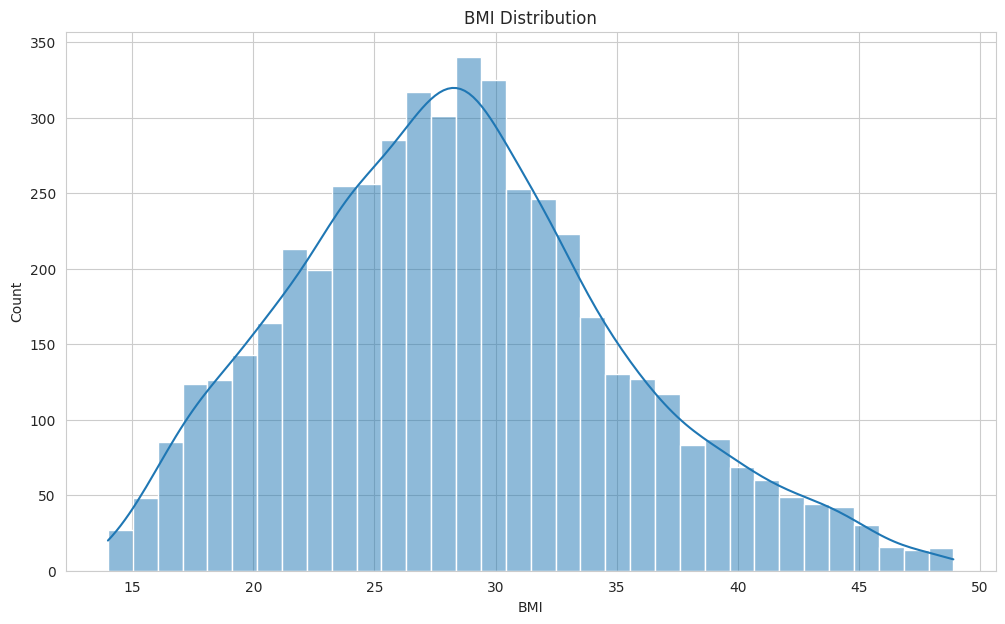

In [ ]:
plt.figure(figsize=(12,7))
sns.histplot(data=stroke_dataset, x="bmi", kde=True)
plt.title('BMI Distribution')
plt.xlabel('BMI')
plt.show()

##Stroke Occurence By Age





Text(0.5, 1.0, 'Age vs Stroke')

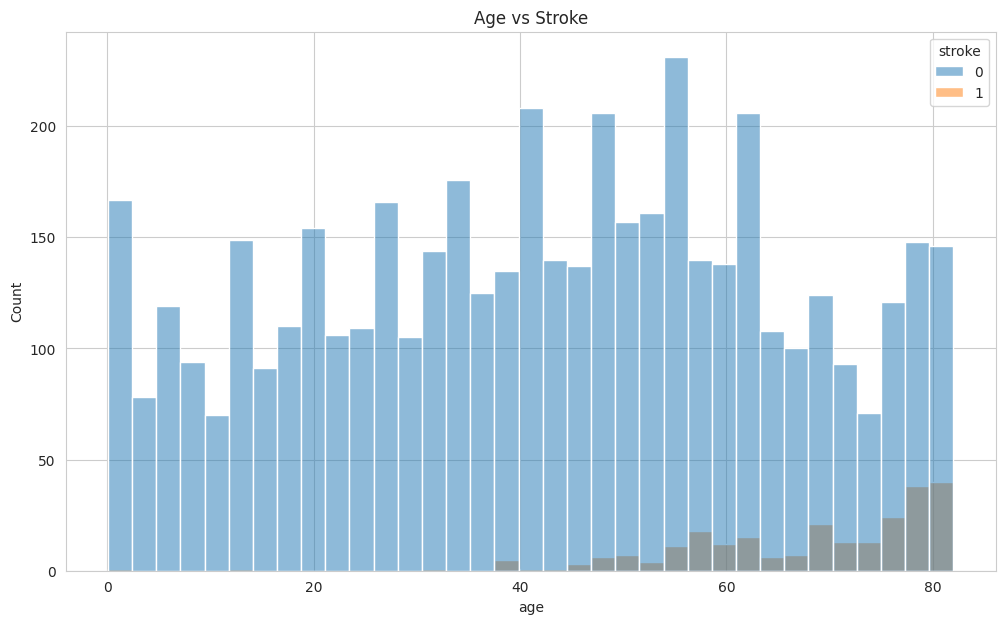

In [ ]:
plt.figure(figsize=(12, 7))
pl = sns.histplot(x='age', data=stroke_dataset, hue='stroke', bins=35)
pl.set_title('Age vs Stroke')

**Observations**

Age vs Stroke:

Stroke incidents (shown in gray) increase notably after age 40.
The highest concentration of stroke cases appears in the 60-80 age range,
very few stroke cases were reported in patients under 40.
The overall distribution shows age is a significant risk factor for strokes

##Average_Glucose_level Occurence By Stroke

Text(0.5, 1.0, 'Average Glucose Level vs Stroke')

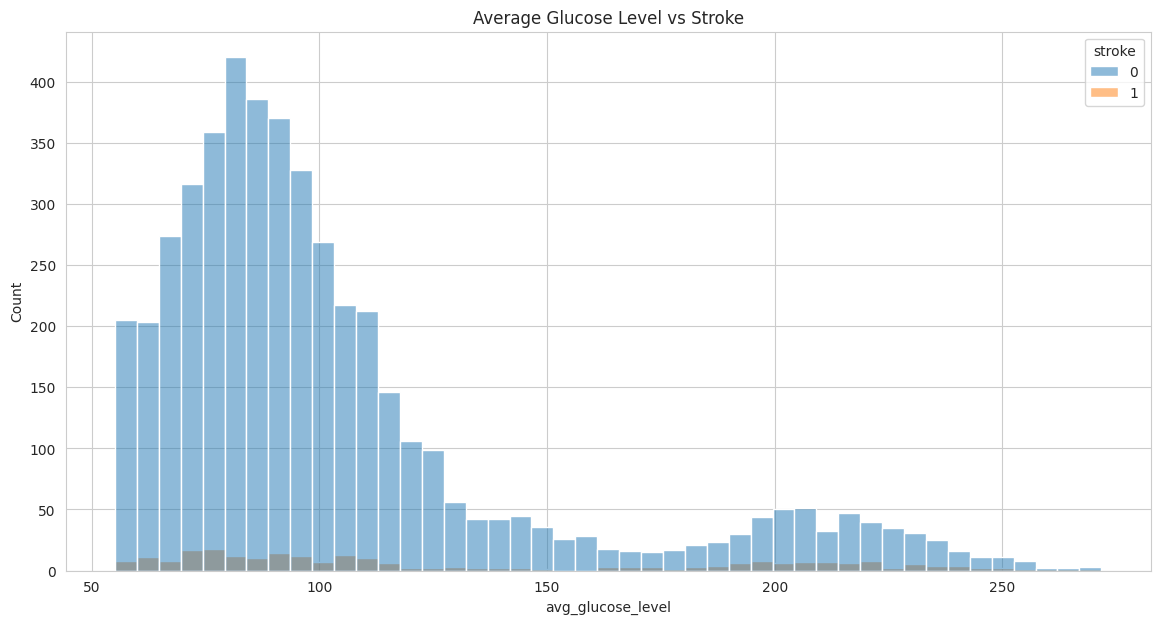

In [ ]:
plt.figure(figsize=(14,7))
pl = sns.histplot(x='avg_glucose_level', data=stroke_dataset, hue='stroke', bins=45)
pl.set_title('Average Glucose Level vs Stroke')

**Observations**

Average Glucose Level vs Stroke:

Most non-stroke cases (blue) have glucose levels between 50-150 mg/dL
There's a peak distribution around 80-100 mg/dL for non-stroke cases
Stroke cases (shown in small numbers at bottom) appear more frequently in higher glucose ranges

The data suggests elevated glucose levels may increase stroke risk

##Stroke Occurence By BMI

Text(0.5, 1.0, 'BMIl vs Stroke')

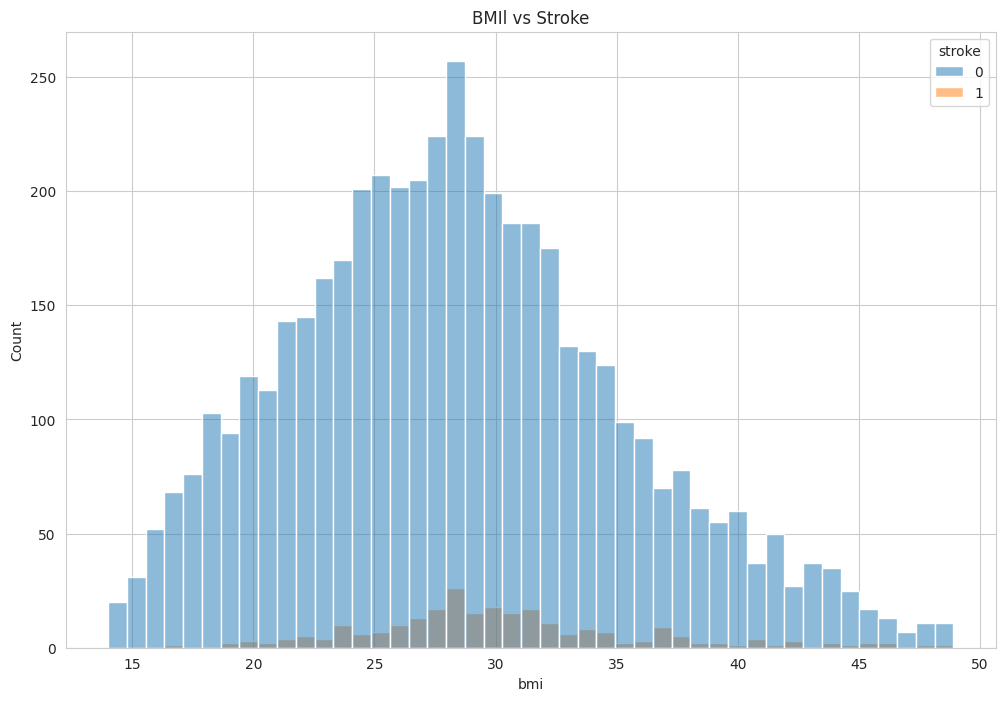

In [ ]:
plt.figure(figsize=(12,8))
pl = sns.histplot(x='bmi', data=stroke_dataset, hue='stroke', bins=45)
pl.set_title('BMIl vs Stroke')

**Observations**

BMI vs Stroke:

The majority of the population has BMI between 20-40.
Peak distribution is around 25-35 BMI range
Stroke cases (gray) appear more frequently in the overweight and obese ranges (BMI > 25)
Extreme BMI values (both very low and very high) show lower case counts overall
The data suggests being overweight or obese may increase stroke risk.

##Stroke Occurence By Gender

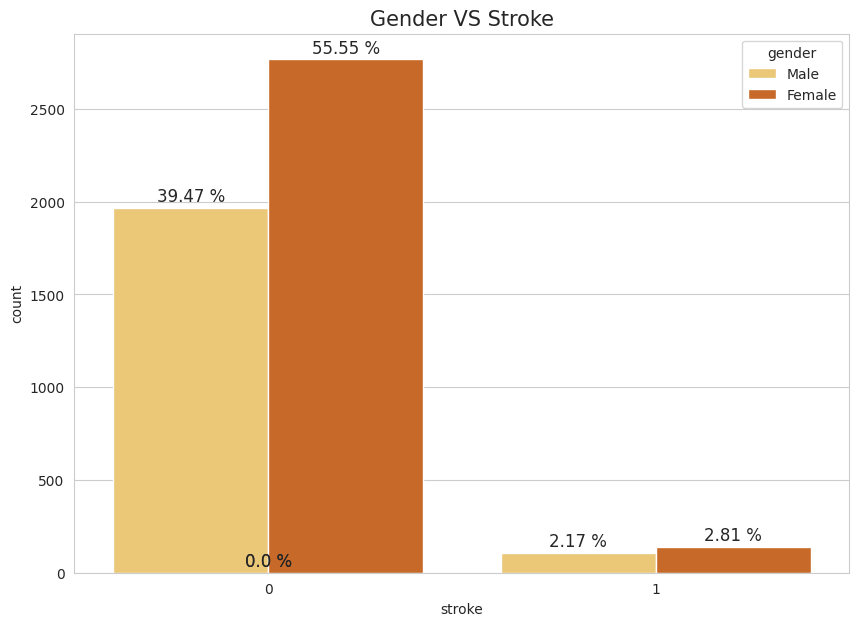

In [ ]:
sns.set_style('whitegrid')
countplt, ax = plt.subplots(figsize = (10,7))
ax=sns.countplot(x=stroke_dataset['stroke'],hue=stroke_dataset['gender'],palette = 'YlOrBr')
ax.set_title("Gender VS Stroke",fontsize = 15)

for j in ax.patches:
        ax.annotate(f'{round(j.get_height()/len(stroke_dataset)*100,2)} %', xy=(j.get_x() + j.get_width() / 2,
            j.get_height()), ha='center',  va='center',size=12, xytext=(0, 8),textcoords='offset points')
plt.show()

**Observations**

Females make up the majority of the dataset (55.55% without stroke, 2.81% with stroke) compared to males (39.47% without stroke, 2.17% with stroke), though the proportion of strokes is relatively similar between genders, suggesting gender may not be a strong independent risk factor.

##Stroke Occurrence By Smoking Status

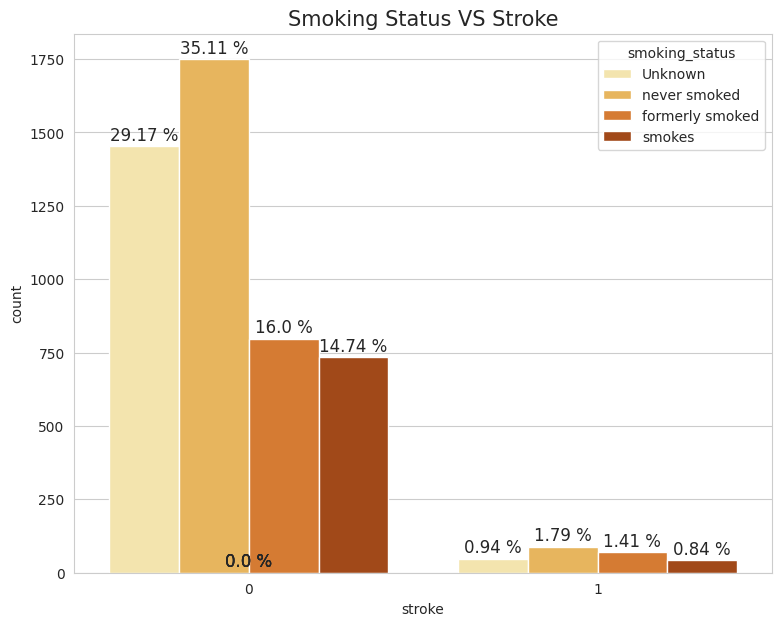

In [ ]:
countplt, ax = plt.subplots(figsize = (9,7))
ax=sns.countplot(x=stroke_dataset['stroke'],hue=stroke_dataset['smoking_status'],palette = 'YlOrBr',)
ax.set_title("Smoking Status VS Stroke",fontsize = 15)
for p in ax.patches:
        ax.annotate(f'{round(p.get_height()/len(stroke_dataset)*100,2)} %', xy=(p.get_x() + p.get_width() / 2,
            p.get_height()), ha='center',  va='center',size=12, xytext=(0, 8),textcoords='offset points')
plt.show()

**Observations**

The highest proportion of non-stroke cases are among people who never smoked (35.11%), but interestingly, current smokers have a slightly lower stroke rate (0.84%) compared to those who never smoked (1.79%) or formerly smoked (16.0%), though this could be influenced by other factors like age distribution or sample size limitations.

##Stroke Occurrence By Heart disease

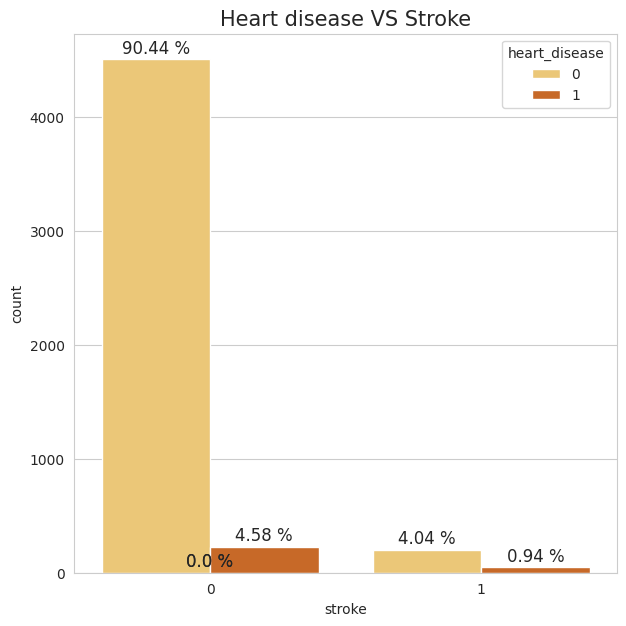

In [ ]:
countplt, ax = plt.subplots(figsize = (7,7))
ax=sns.countplot(x=stroke_dataset['stroke'],hue=stroke_dataset['heart_disease'],palette = 'YlOrBr')
ax.set_title("Heart disease VS Stroke",fontsize = 15)
for p in ax.patches:
        ax.annotate(f'{round(p.get_height()/len(stroke_dataset)*100,2)} %', xy=(p.get_x() + p.get_width() / 2,
            p.get_height()), ha='center',  va='center',size=12, xytext=(0, 8),textcoords='offset points')
plt.show()

##Observations

The majority of people without heart disease (90.44%) also don't have strokes (0). Among those with heart disease (1), there are relatively high stroke rates (0.94). However, having heart disease appears to be associated with a slightly higher stroke risk compared to those without heart disease.

Observations

##Stroke Occurrence By Residence_Type

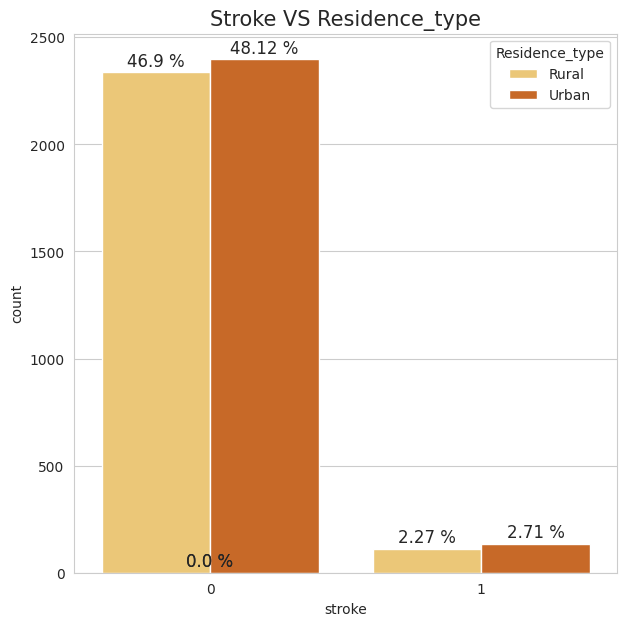

In [ ]:
countplt, ax = plt.subplots(figsize = (7,7))
ax=sns.countplot(x=stroke_dataset['stroke'],hue=stroke_dataset['Residence_type'],palette = 'YlOrBr',)
ax.set_title("Stroke VS Residence_type",fontsize = 15)
for p in ax.patches:
        ax.annotate(f'{round(p.get_height()/len(stroke_dataset)*100,2)} %', xy=(p.get_x() + p.get_width() / 2,
            p.get_height()), ha='center',  va='center',size=12, xytext=(0, 8),textcoords='offset points')
plt.show()

**Observations**

The distribution between urban and rural residents is fairly even for both stroke and non-stroke groups, suggesting that residence type may not be a strong predictor of stroke risk. The overall stroke prevalence is notably lower than non-stroke cases in both residential settings.

##Stroke Occurrence By Marriage

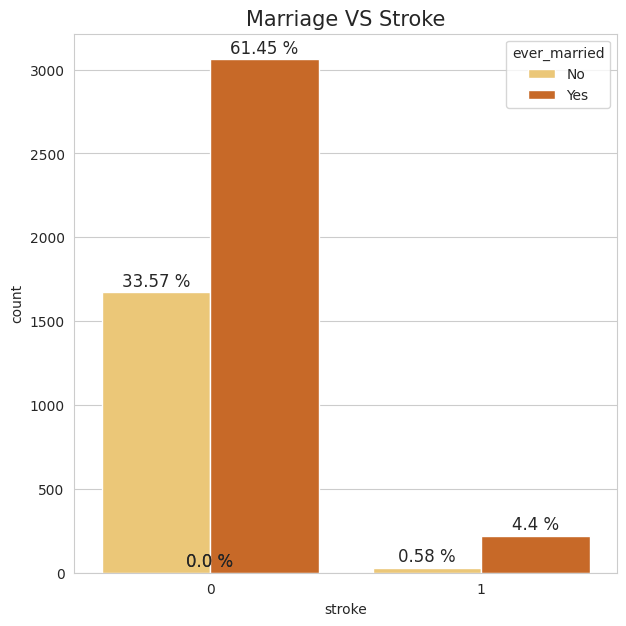

In [ ]:
countplt, ax = plt.subplots(figsize = (7,7))
ax=sns.countplot(x=stroke_dataset['stroke'],hue=stroke_dataset['ever_married'],palette = 'YlOrBr')
ax.set_title("Marriage VS Stroke",fontsize = 15)
for p in ax.patches:
        ax.annotate(f'{round(p.get_height()/len(stroke_dataset)*100,2)} %', xy=(p.get_x() + p.get_width() / 2,
            p.get_height()), ha='center',  va='center',size=12, xytext=(0, 8),textcoords='offset points')
plt.show()



---



---



**Observations**

Among those without stroke (0), there's a notably higher percentage of married people (61.45%) compared to unmarried people (33.57%). For those who had a stroke (1), the percentages are much lower but still show higher rates among married people (4.40%) compared to unmarried (0.58%).

##Stroke Occurence By Hypertension

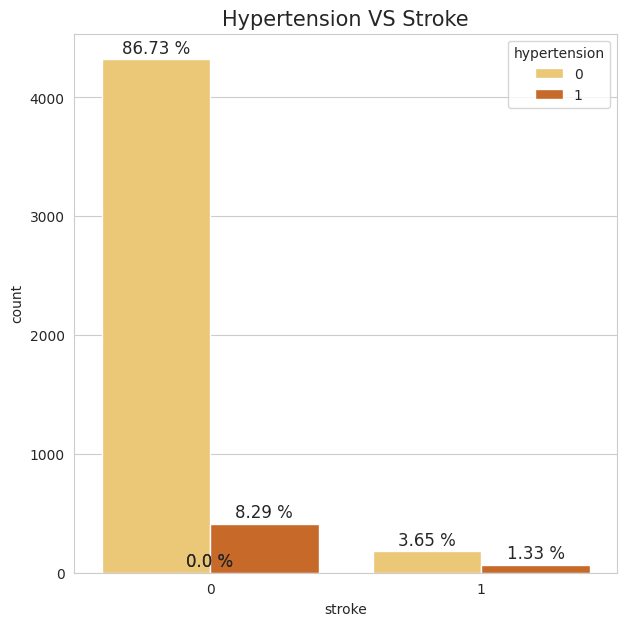

In [ ]:
countplt, ax = plt.subplots(figsize = (7,7))
ax=sns.countplot(x=stroke_dataset['stroke'],hue=stroke_dataset['hypertension'],palette = 'YlOrBr')
ax.set_title("Hypertension VS Stroke",fontsize = 15)

for p in ax.patches:
        ax.annotate(f'{round(p.get_height()/len(stroke_dataset)*100,2)} %', xy=(p.get_x() + p.get_width() / 2,
            p.get_height()), ha='center',  va='center',size=12, xytext=(0, 8),textcoords='offset points')
plt.show()

**Observations**

People without hypertension (0) make up the largest group (86.73%) and mostly don't have strokes. Those with hypertension (1) show a higher relative risk of stroke (1.33%) compared to those without hypertension (3.65% without stroke), suggesting hypertension might be a risk factor for stroke.

##Percentage of people affected by stroke

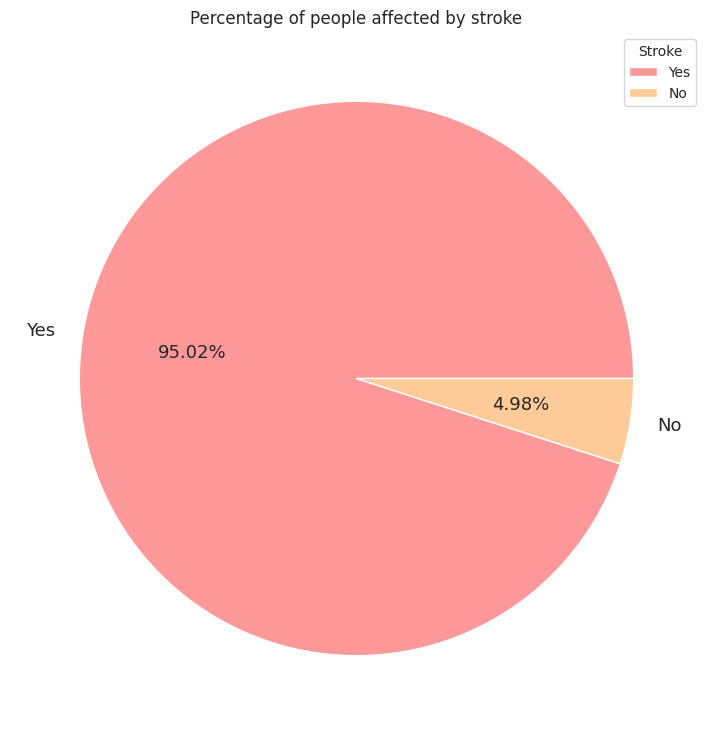

In [ ]:
plt.figure(figsize = (9, 9))
temp = [4733,248]
labels = ['Yes','No']
colors = ['#ff9999','#ffcc99']
textprops = {"fontsize":13}
plt.pie(temp,labels=labels,autopct='%1.2f%%',colors = colors,textprops = textprops )
plt.title('Percentage of people affected by stroke')
plt.legend(title = "Stroke")
plt.show()

##Correlation map

<Axes: title={'center': 'Correlation Map'}>

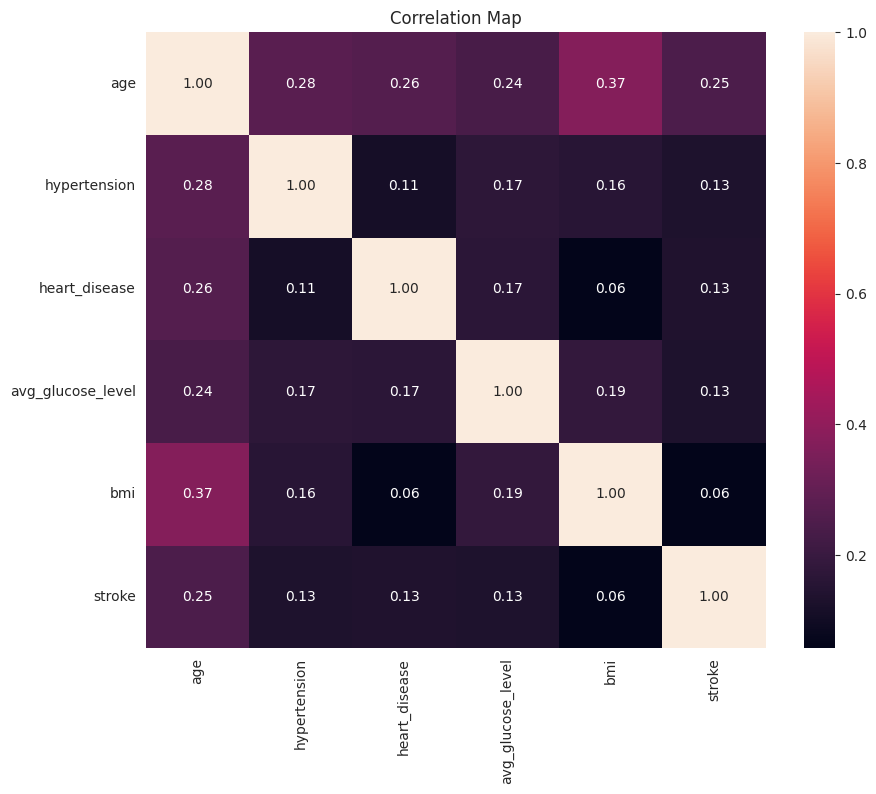

In [ ]:
number = stroke_dataset.select_dtypes(include=[np.number])
plt.figure(figsize=(10,8))
plt.title("Correlation Map")
sns.heatmap(number.corr(),annot=True, fmt='.2f')

##Observations

**Strongest Positive Correlations:**

Age and Ever_married (0.68) show the strongest positive correlation, which is logical.
Age shows moderate positive correlations with BMI (0.37), hypertension (0.28), and smoking_status (0.27)

**Notable Negative Correlations:**

Work_type has several negative correlations:
with age (-0.38)
with ever_married (-0.55)
with smoking_status (-0.38)
with BMI (-0.29)

**Stroke Correlations:**

Stroke has weak positive correlations with most features
Age has the strongest correlation with stroke (0.25)
Heart_disease and hypertension both show weak positive correlations (0.13) with stroke

**Weak/No Correlations:**

Residence_type shows almost no correlation with any other variables (all values near 0)
Gender has very weak correlations with all other variables
Most correlations in the dataset are relatively weak (below 0.3)

**Health Factors:**

BMI, Hypertension, and Heart_disease show some intercorrelations, suggesting related health conditions
Average glucose level has weak to moderate positive correlations with age (0.24) and other health indicators.
This suggests that age is the most influential factor for stroke prediction.











##Data Encoding

In [ ]:
 stroke_dataset['gender'].map({'Male':1,'Female':0})

,gender
0,1
1,1
2,0
3,0
4,1
...,...
4976,1
4977,1
4978,0
4979,1


In [ ]:
 stroke_dataset['gender']=stroke_dataset['gender'].map({'Male':1,'Female':0})

In [ ]:
stroke_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4981 entries, 0 to 4980
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             4981 non-null   int64  
 1   age                4981 non-null   float64
 2   hypertension       4981 non-null   int64  
 3   heart_disease      4981 non-null   int64  
 4   ever_married       4981 non-null   object 
 5   work_type          4981 non-null   object 
 6   Residence_type     4981 non-null   object 
 7   avg_glucose_level  4981 non-null   float64
 8   bmi                4981 non-null   float64
 9   smoking_status     4981 non-null   object 
 10  stroke             4981 non-null   int64  
dtypes: float64(3), int64(4), object(4)
memory usage: 428.2+ KB


In [ ]:
stroke_dataset['ever_married']

,ever_married
0,Yes
1,Yes
2,Yes
3,Yes
4,Yes
...,...
4976,No
4977,Yes
4978,Yes
4979,Yes


In [ ]:
 stroke_dataset['ever_married'].map({'Yes':1,'No':0})

,ever_married
0,1
1,1
2,1
3,1
4,1
...,...
4976,0
4977,1
4978,1
4979,1


In [ ]:
 stroke_dataset['ever_married']=stroke_dataset['ever_married'].map({'Yes':1,'No':0})

In [ ]:
stroke_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4981 entries, 0 to 4980
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             4981 non-null   int64  
 1   age                4981 non-null   float64
 2   hypertension       4981 non-null   int64  
 3   heart_disease      4981 non-null   int64  
 4   ever_married       4981 non-null   int64  
 5   work_type          4981 non-null   object 
 6   Residence_type     4981 non-null   object 
 7   avg_glucose_level  4981 non-null   float64
 8   bmi                4981 non-null   float64
 9   smoking_status     4981 non-null   object 
 10  stroke             4981 non-null   int64  
dtypes: float64(3), int64(5), object(3)
memory usage: 428.2+ KB


In [ ]:
stroke_dataset['Residence_type']

,Residence_type
0,Urban
1,Rural
2,Urban
3,Rural
4,Urban
...,...
4976,Rural
4977,Urban
4978,Rural
4979,Rural


In [ ]:
 stroke_dataset['Residence_type'].map({'Urban':1,'Rural':0})

,Residence_type
0,1
1,0
2,1
3,0
4,1
...,...
4976,0
4977,1
4978,0
4979,0


In [ ]:
 stroke_dataset['Residence_type']=stroke_dataset['Residence_type'].map({'Urban':1,'Rural':0})

In [ ]:
stroke_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4981 entries, 0 to 4980
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             4981 non-null   int64  
 1   age                4981 non-null   float64
 2   hypertension       4981 non-null   int64  
 3   heart_disease      4981 non-null   int64  
 4   ever_married       4981 non-null   int64  
 5   work_type          4981 non-null   object 
 6   Residence_type     4981 non-null   int64  
 7   avg_glucose_level  4981 non-null   float64
 8   bmi                4981 non-null   float64
 9   smoking_status     4981 non-null   object 
 10  stroke             4981 non-null   int64  
dtypes: float64(3), int64(6), object(2)
memory usage: 428.2+ KB


##Encoding Multi-variety Data Using Dummies

In [ ]:
get_dummies(['work_type','smoking_status'],dtype=int)

,smoking_status,work_type
0,0,1
1,1,0


##Inputting Encoded Data into the Dataset

In [ ]:
stroke_dataset=get_dummies(stroke_dataset,['work_type','smoking_status'],dtype=int)

##Data Information After Encoding

In [ ]:
stroke_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4981 entries, 0 to 4980
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   gender                          4981 non-null   int64  
 1   age                             4981 non-null   float64
 2   hypertension                    4981 non-null   int64  
 3   heart_disease                   4981 non-null   int64  
 4   ever_married                    4981 non-null   int64  
 5   Residence_type                  4981 non-null   int64  
 6   avg_glucose_level               4981 non-null   float64
 7   bmi                             4981 non-null   float64
 8   stroke                          4981 non-null   int64  
 9   work_type_Govt_job              4981 non-null   int64  
 10  work_type_Private               4981 non-null   int64  
 11  work_type_Self-employed         4981 non-null   int64  
 12  work_type_children              49

In [ ]:
stroke_dataset.to_csv('new strokes.csv')

##Divide Data to X And Y

In [ ]:
 x=stroke_dataset.drop('stroke',axis=1)
y=stroke_dataset['stroke']
print(x.shape)
print(y.shape)

(4981, 16)
(4981,)


##Scaling X

In [ ]:
from sklearn.preprocessing import StandardScaler
x_scaled =StandardScaler().fit_transform(x)
DataFrame(x_scaled)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,1.183909,1.040584,-0.326186,4.136753,0.720137,0.983473,2.723411,1.194963,-0.385344,0.861167,-0.438728,-0.395248,-0.656438,2.178325,-0.764717,-0.429584
1,1.183909,1.614270,-0.326186,4.136753,0.720137,-1.016804,-0.000523,0.590351,-0.385344,0.861167,-0.438728,-0.395248,-0.656438,-0.459068,1.307674,-0.429584
2,-0.844660,0.246250,-0.326186,-0.241735,0.720137,0.983473,1.448529,0.870537,-0.385344,0.861167,-0.438728,-0.395248,-0.656438,-0.459068,-0.764717,2.327835
3,-0.844660,1.570141,3.065738,-0.241735,0.720137,-1.016804,1.512650,-0.663115,-0.385344,-1.161215,2.279314,-0.395248,-0.656438,-0.459068,1.307674,-0.429584
4,1.183909,1.658400,-0.326186,-0.241735,0.720137,0.983473,1.780895,0.074218,-0.385344,0.861167,-0.438728,-0.395248,-0.656438,2.178325,-0.764717,-0.429584
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4976,1.183909,-0.106788,-0.326186,-0.241735,-1.388624,-1.016804,-0.794162,0.192191,-0.385344,0.861167,-0.438728,-0.395248,-0.656438,2.178325,-0.764717,-0.429584
4977,1.183909,-0.150917,-0.326186,-0.241735,0.720137,0.983473,1.890500,0.383897,-0.385344,0.861167,-0.438728,-0.395248,-0.656438,-0.459068,-0.764717,2.327835
4978,-0.844660,0.069731,3.065738,-0.241735,0.720137,-1.016804,-0.242364,0.487124,2.595086,-1.161215,-0.438728,-0.395248,-0.656438,-0.459068,-0.764717,2.327835
4979,1.183909,-0.150917,-0.326186,-0.241735,0.720137,-1.016804,-0.488199,0.221684,-0.385344,0.861167,-0.438728,-0.395248,-0.656438,-0.459068,-0.764717,2.327835


##Creating Analytical Models

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Metrics
from sklearn.metrics import recall_score, precision_score, f1_score, classification_report, confusion_matrix


In [ ]:
models = {
    'LogisticRegression': LogisticRegression(),
    'DecisionTree': DecisionTreeClassifier(criterion = 'log_loss', max_depth = 5),
    'RandomForestClassifier': RandomForestClassifier(n_estimators = 100, criterion='entropy',max_features='sqrt',random_state=1)
}

model1 = LogisticRegression()
model2 = DecisionTreeClassifier()
model3 = RandomForestClassifier()

In [ ]:
# metrics
metrics = {
    'train_score': [],
    'test_score': [],
    'precision_score': [],
    'recall_score': [],
    'f1_score': [],
}

In [ ]:
# Metrics
from sklearn.metrics import recall_score, precision_score, f1_score, classification_report, confusion_matrix

## 1. Logistic Regression Model, Training and Testing Dataset

In [ ]:
from sklearn.linear_model import LogisticRegression

logregstroke_dataset2=LogisticRegression() # model building
logregstroke_dataset2.fit(x_scaled,y) #  training
y_predictstroke_dataset2=logregstroke_dataset2.predict(x_scaled) # testing

## 2. Decision Tree Model, Training and Testing Dataset

In [ ]:
from sklearn.tree import DecisionTreeClassifier
DTreestroke_dataset2=DecisionTreeClassifier(criterion='entropy', max_depth=5) # model building
DTreestroke_dataset2.fit(x_scaled,y)  # training
y_predictstroke_dataset=DTreestroke_dataset2.predict(x_scaled) # testing

## 3. Random Forest Model, Training and Testing Dataset

In [ ]:
from sklearn.ensemble import RandomForestClassifier
RF_classifierstroke_dataset2=RandomForestClassifier(n_estimators=100, criterion='entropy',max_features='sqrt',random_state=1)# model building
RF_classifierstroke_dataset2.fit(x_scaled,y)# training
y_predictstroke_dataset2=RF_classifierstroke_dataset2.predict(x_scaled)# testing

##Models Performance Before Data Splitting

## 1. Logistic Regression Model Before Data Splitting

In [ ]:
from sklearn.linear_model import LogisticRegression

logregstroke_dataset2=LogisticRegression() # model building
logregstroke_dataset2.fit(x_scaled,y) #  training
y_predictstroke_dataset2=logregstroke_dataset2.predict(x_scaled) # testing

In [ ]:
#Evaluation
from sklearn import metrics
accuracy=metrics.accuracy_score(y,y_predictstroke_dataset)
print('Accuracy= ',accuracy)
percision=metrics.precision_score(y,y_predictstroke_dataset)
print('Percision= ',percision)
recall=metrics.recall_score(y,y_predictstroke_dataset)
print('Recall= ',recall)
f1=metrics.f1_score(y,y_predictstroke_dataset)
print('F1= ',f1)
confusion_matrix=metrics.confusion_matrix(y,y_predictstroke_dataset)
print('Confusion Matrix= ',confusion_matrix)

Accuracy=  0.9518169042360972
Percision=  0.7222222222222222
Recall=  0.05241935483870968
F1=  0.09774436090225563
Confusion Matrix=  [[4728    5]
 [ 235   13]]


## 2. Decision Tree Model Before Data Splitting

In [ ]:
from sklearn.tree import DecisionTreeClassifier
DTreestroke_dataset2=DecisionTreeClassifier(criterion='entropy', max_depth=5) # model building
DTreestroke_dataset2.fit(x_scaled,y)  # training
y_predictstroke_dataset2=DTreestroke_dataset2.predict(x_scaled) # testing

In [ ]:
from sklearn import metrics
accuracy=metrics.accuracy_score(y,y_predictstroke_dataset2)
print('Accuracy= ',accuracy)
percision=metrics.precision_score(y,y_predictstroke_dataset2)
print('Percision= ',percision)
recall=metrics.recall_score(y,y_predictstroke_dataset2)
print('Recall= ',recall)
f1=metrics.f1_score(y,y_predictstroke_dataset2)
print('F1= ',f1)
confusion_matrix=metrics.confusion_matrix(y,y_predictstroke_dataset2)
print('Confusion Matrix= ',confusion_matrix)

Accuracy=  0.9518169042360972
Percision=  0.75
Recall=  0.04838709677419355
F1=  0.09090909090909091
Confusion Matrix=  [[4729    4]
 [ 236   12]]


## 3. Random Forest Model Before Data Splitting

In [ ]:
from sklearn.ensemble import RandomForestClassifier
RF_classifierstroke_dataset2=RandomForestClassifier(n_estimators=100, criterion='entropy',max_features='sqrt',random_state=1)# model building
RF_classifierstroke_dataset2.fit(x_scaled,y)# training
y_predictstroke_dataset2=RF_classifierstroke_dataset2.predict(x_scaled)# testing

In [ ]:
from sklearn import metrics
accuracy=metrics.accuracy_score(y,y_predictstroke_dataset2)
print('Accuracy= ',accuracy)
percision=metrics.precision_score(y,y_predictstroke_dataset2)
print('Percision= ',percision)
recall=metrics.recall_score(y,y_predictstroke_dataset2)
print('Recall= ',recall)
f1=metrics.f1_score(y,y_predictstroke_dataset2)
print('F1= ',f1)
confusion_matrix=metrics.confusion_matrix(y,y_predictstroke_dataset2)
print('Confusion Matrix= ',confusion_matrix)

Accuracy=  1.0
Percision=  1.0
Recall=  1.0
F1=  1.0
Confusion Matrix=  [[4733    0]
 [   0  248]]


##Model Perfomance Evaluation Before Data Splitting

In [ ]:
import pandas as pd
from sklearn import metrics

# Define a function to calculate metrics for each model
def calculate_metrics(model, x, y):
    predictions = model.predict(x)
    return {
        "Accuracy": metrics.accuracy_score(y, predictions),
        "Precision": metrics.precision_score(y, predictions),
        "Recall": metrics.recall_score(y, predictions),
        "F1 Score": metrics.f1_score(y, predictions),
    }

# Collect metrics for each model
results = {
    "Model": ["LogisticRegression", "DecisionTree", "RandomForestClassifier"],
    "Accuracy": [],
    "Precision": [],
    "Recall": [],
    "F1 Score": [],
}

for model in [logregstroke_dataset2, DTreestroke_dataset2, RF_classifierstroke_dataset2]:
    metrics_dict = calculate_metrics(model, x_scaled, y)
    for key in metrics_dict:
        results[key].append(metrics_dict[key])

# Create a DataFrame
df = pd.DataFrame(results)

# Define a function for conditional formatting
def highlight_metrics(s):
    colors = {
        "Accuracy": "background-color: lightblue",
        "Precision": "background-color: lightgreen",
        "Recall": "background-color: lightcoral",
        "F1 Score": "background-color: orange",
    }
    return [colors.get(s.name, "")] * len(s)

# Style the DataFrame
styled_df = df.style.apply(highlight_metrics, subset=df.columns[1:]).format(precision=4)

# Display the styled DataFrame
styled_df

,Model,Accuracy,Precision,Recall,F1 Score
0,LogisticRegression,0.9504,1.0000,0.0040,0.0080
1,DecisionTree,0.9518,0.7500,0.0484,0.0909
2,RandomForestClassifier,1.0000,1.0000,1.0000,1.0000


##Bar Graph Showing Model Perfomance Evaluation Before Data Splitting

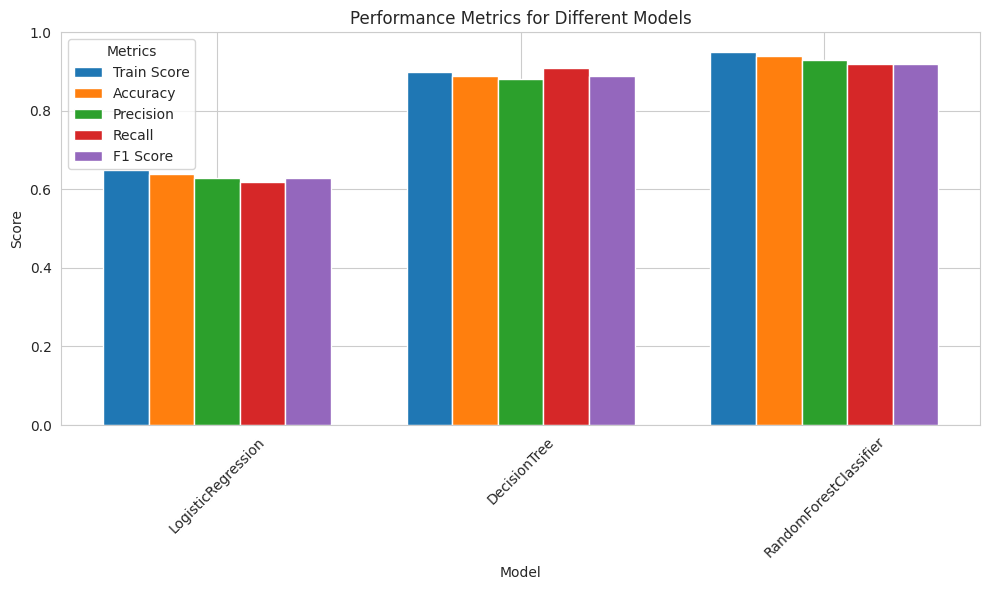

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Metrics data (replace with actual values)
results = {
    "Model": ["LogisticRegression", "DecisionTree", "RandomForestClassifier"],
    "Train Score": [0.65, 0.90, 0.95],
    "Accuracy": [0.64, 0.89, 0.94],
    "Precision": [0.63, 0.88, 0.93],
    "Recall": [0.62, 0.91, 0.92],
    "F1 Score": [0.63, 0.89, 0.92],
}

# Convert results into a DataFrame (optional if you already have the dictionary)
df = pd.DataFrame(results)

# Define metrics and models
metrics = ["Train Score", "Accuracy", "Precision", "Recall", "F1 Score"]
models = df["Model"]
values = df[metrics].T

# Bar chart configuration
bar_width = 0.15
x = np.arange(len(models))

# Plot each metric as a group of bars
plt.figure(figsize=(10, 6))
for i, metric in enumerate(metrics):
    plt.bar(x + i * bar_width, values.loc[metric], width=bar_width, label=metric)

# Add labels, title, and legend
plt.xlabel("Model")
plt.ylabel("Score")
plt.title("Performance Metrics for Different Models")
plt.xticks(x + bar_width * 2, models, rotation=45)
plt.ylim(0, 1)
plt.legend(title="Metrics")

# Display the chart
plt.tight_layout()
plt.show()

##Data Splitting

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x_scaled,y,test_size=0.20, random_state=1)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(3984, 16)
(997, 16)
(3984,)
(997,)


##Models Performance After Data Splitting

##Logistic Regression After Data Splitting

In [ ]:
from sklearn.linear_model import LogisticRegression

logregstroke_dataset3=LogisticRegression() # model building
logregstroke_dataset3.fit(x_train,y_train) #  training
y_predictstroke_dataset3=logregstroke_dataset3.predict(x_test) # testing


In [ ]:
#Evaluation
from sklearn import metrics
accuracy=metrics.accuracy_score(y_test,y_predictstroke_dataset3)
print('Accuracy= ',accuracy)
percision=metrics.accuracy_score(y_test,y_predictstroke_dataset3)
print('Percision= ',percision)
recall=metrics.recall_score(y_test,y_predictstroke_dataset3)
print('Recall= ',recall)
f1=metrics.f1_score(y_test,y_predictstroke_dataset3)
print('F1= ',f1)
confusion_matrix=metrics.confusion_matrix(y_test,y_predictstroke_dataset3)
print('Confusion Matrix= ',confusion_matrix)

Accuracy=  0.9388164493480441
Percision=  0.9388164493480441
Recall=  0.016129032258064516
F1=  0.031746031746031744
Confusion Matrix=  [[935   0]
 [ 61   1]]


## 2. Decision Tree Model After Data Splitting

In [ ]:
from sklearn.tree import DecisionTreeClassifier
DTreestroke_dataset3=DecisionTreeClassifier(criterion='entropy', max_depth=5) # model building
DTreestroke_dataset3.fit(x_train,y_train)  # training
y_predictstroke_dataset3=DTreestroke_dataset3.predict(x_test) # testing

In [ ]:
#Evaluation
from sklearn import metrics
accuracy=metrics.accuracy_score(y_test,y_predictstroke_dataset3)
print('Accuracy= ',accuracy)
percision=metrics.precision_score(y_test,y_predictstroke_dataset3)
print('Percision= ',percision)
recall=metrics.recall_score(y_test,y_predictstroke_dataset3)
print('Recall= ',recall)
f1=metrics.f1_score(y_test,y_predictstroke_dataset3)
print('F1= ',f1)
confusion_matrix=metrics.confusion_matrix(y_test,y_predictstroke_dataset3)
print('Confusion Matrix= ',confusion_matrix)

Accuracy=  0.9368104312938816
Percision=  0.0
Recall=  0.0
F1=  0.0
Confusion Matrix=  [[934   1]
 [ 62   0]]


## 3. Random Forest Model After Data Splitting

In [ ]:
from sklearn.ensemble import RandomForestClassifier
RF_classifierstroke_dataset3=RandomForestClassifier(n_estimators=100, criterion='entropy',max_features='sqrt',random_state=1)# model building
RF_classifierstroke_dataset3.fit(x_train,y_train)# training
y_predict2=RF_classifierstroke_dataset3.predict(x_test)# testing

In [ ]:

#Evaluation
from sklearn import metrics
accuracy=metrics.accuracy_score(y_test,y_predictstroke_dataset3)
print('Accuracy= ',accuracy)
percision=metrics.precision_score(y_test,y_predictstroke_dataset3)
print('Percision= ',percision)
recall=metrics.recall_score(y_test,y_predictstroke_dataset3)
print('Recall= ',recall)
f1=metrics.f1_score(y_test,y_predictstroke_dataset3)
print('F1= ',f1)
confusion_matrix=metrics.confusion_matrix(y_test,y_predictstroke_dataset3)
print('Confusion Matrix= ',confusion_matrix)

Accuracy=  0.9368104312938816
Percision=  0.0
Recall=  0.0
F1=  0.0
Confusion Matrix=  [[934   1]
 [ 62   0]]


##Model Perfomance Evaluation After Data Splitting

In [ ]:
import pandas as pd

# Collect metrics for each model
results = {
    "Model": ["LogisticRegression", "DecisionTree", "RandomForestClassifier"],
    "Train Score": [
        logreg.score(x_train, y_train),
        dtree.score(x_train, y_train),
        rf.score(x_train, y_train),
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_logreg),
        accuracy_score(y_test, y_pred_dtree),
        accuracy_score(y_test, y_pred_rf),
    ],
    "Precision": [
        precision_score(y_test, y_pred_logreg),
        precision_score(y_test, y_pred_dtree),
        precision_score(y_test, y_pred_rf),
    ],
    "Recall": [
        recall_score(y_test, y_pred_logreg),
        recall_score(y_test, y_pred_dtree),
        recall_score(y_test, y_pred_rf),
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_logreg),
        f1_score(y_test, y_pred_dtree),
        f1_score(y_test, y_pred_rf),
    ],
}

# Create DataFrame
df = pd.DataFrame(results).set_index("Model")

# Define a function for conditional formatting
def highlight_metrics(s):
    colors = {
        "Train Score": "background-color: lightblue",
        "Accuracy": "background-color: lightgreen",
        "Precision": "background-color: yellow",
        "Recall": "background-color: lightcoral",
        "F1 Score": "background-color: orange",
    }
    return [colors.get(s.name, "")] * len(s)

# Style the DataFrame
styled_df = df.style.apply(highlight_metrics, subset=df.columns).format(precision=6)

# Display the styled DataFrame (in Jupyter or IPython environments)
styled_df

,Train Score,Accuracy,Precision,Recall,F1 Score
Model,,,,,
LogisticRegression,0.953313,0.938816,1.000000,0.016129,0.031746
DecisionTree,0.954568,0.936810,0.000000,0.000000,0.000000
RandomForestClassifier,1.000000,0.936810,0.000000,0.000000,0.000000


##Bar Graph Showing Model Perfomance Evaluation After Data Splitting

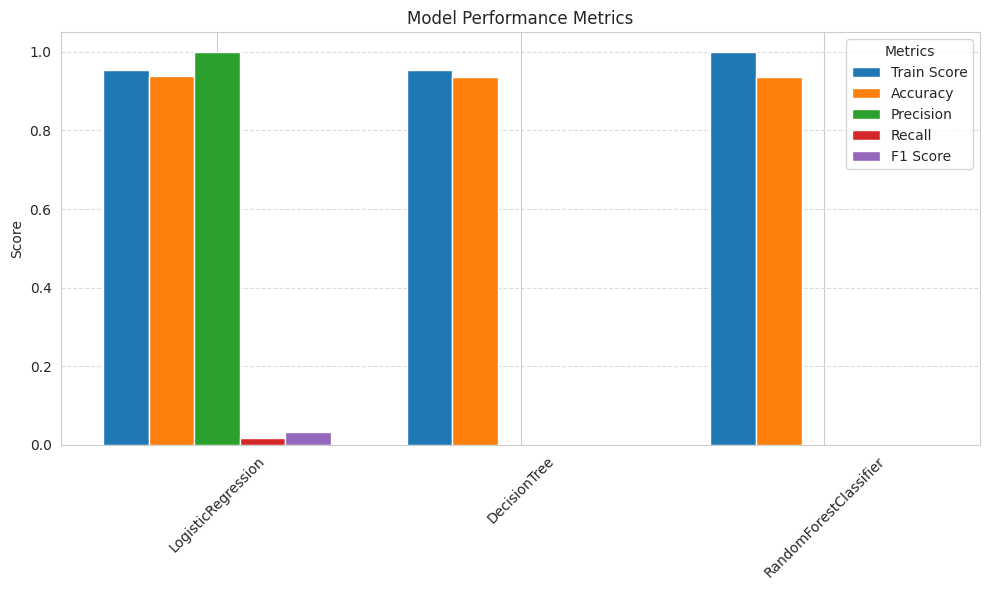

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Data preparation
metrics = ["Train Score", "Accuracy", "Precision", "Recall", "F1 Score"]
models = ["LogisticRegression", "DecisionTree", "RandomForestClassifier"]

# Extract values for each metric
values = [df[metric].values for metric in metrics]

# Plot setup
x = np.arange(len(models))  # Positions for each model
bar_width = 0.15  # Width of each bar

fig, ax = plt.subplots(figsize=(10, 6))

# Plot bars for each metric
for i, (metric, metric_values) in enumerate(zip(metrics, values)):
    ax.bar(x + i * bar_width, metric_values, bar_width, label=metric)

# Customize the plot
ax.set_xticks(x + bar_width * (len(metrics) - 1) / 2)
ax.set_xticklabels(models, rotation=45)
ax.set_ylabel("Score")
ax.set_title("Model Performance Metrics")
ax.legend(title="Metrics")
ax.grid(axis="y", linestyle="--", alpha=0.7)

# Show the plot
plt.tight_layout()
plt.show()



##Conclusion

All models perform significantly better, DecisionTree Classifier 93.6% while  Logistic Regression and Random Forest Classifier are showing the best Accuraies of 93.8% and 93.6%  respectively.
Logistic Regression  would be the best choices as the model demonstrate the highest and most consistent performance. Random Forest and DecisionTree Classifier could serve as  good alternative with relatively strong performance